# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [1]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

Importelo usando pandas.

In [3]:
import pandas as pd
df = pd.read_csv(url,sep=r'\s+', names=column_names,na_values="?"
)

### Limpia los datos

Trata los missings y variables categóricas

In [4]:
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [6]:
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].median())

In [7]:
df['Origin'] = df['Origin'].map({1: 'usa', 2: 'europe', 3: 'japan'})

# Aplicamos One-Hot Encoding (esto crea columnas individuales para cada origen)
df = pd.get_dummies(df, columns=['Origin'], prefix='', prefix_sep='')


In [8]:
df.drop("Car name", axis=1, inplace=True)

### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [9]:
from sklearn.model_selection import train_test_split
X = df.drop('MPG', axis=1)
y = df['MPG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

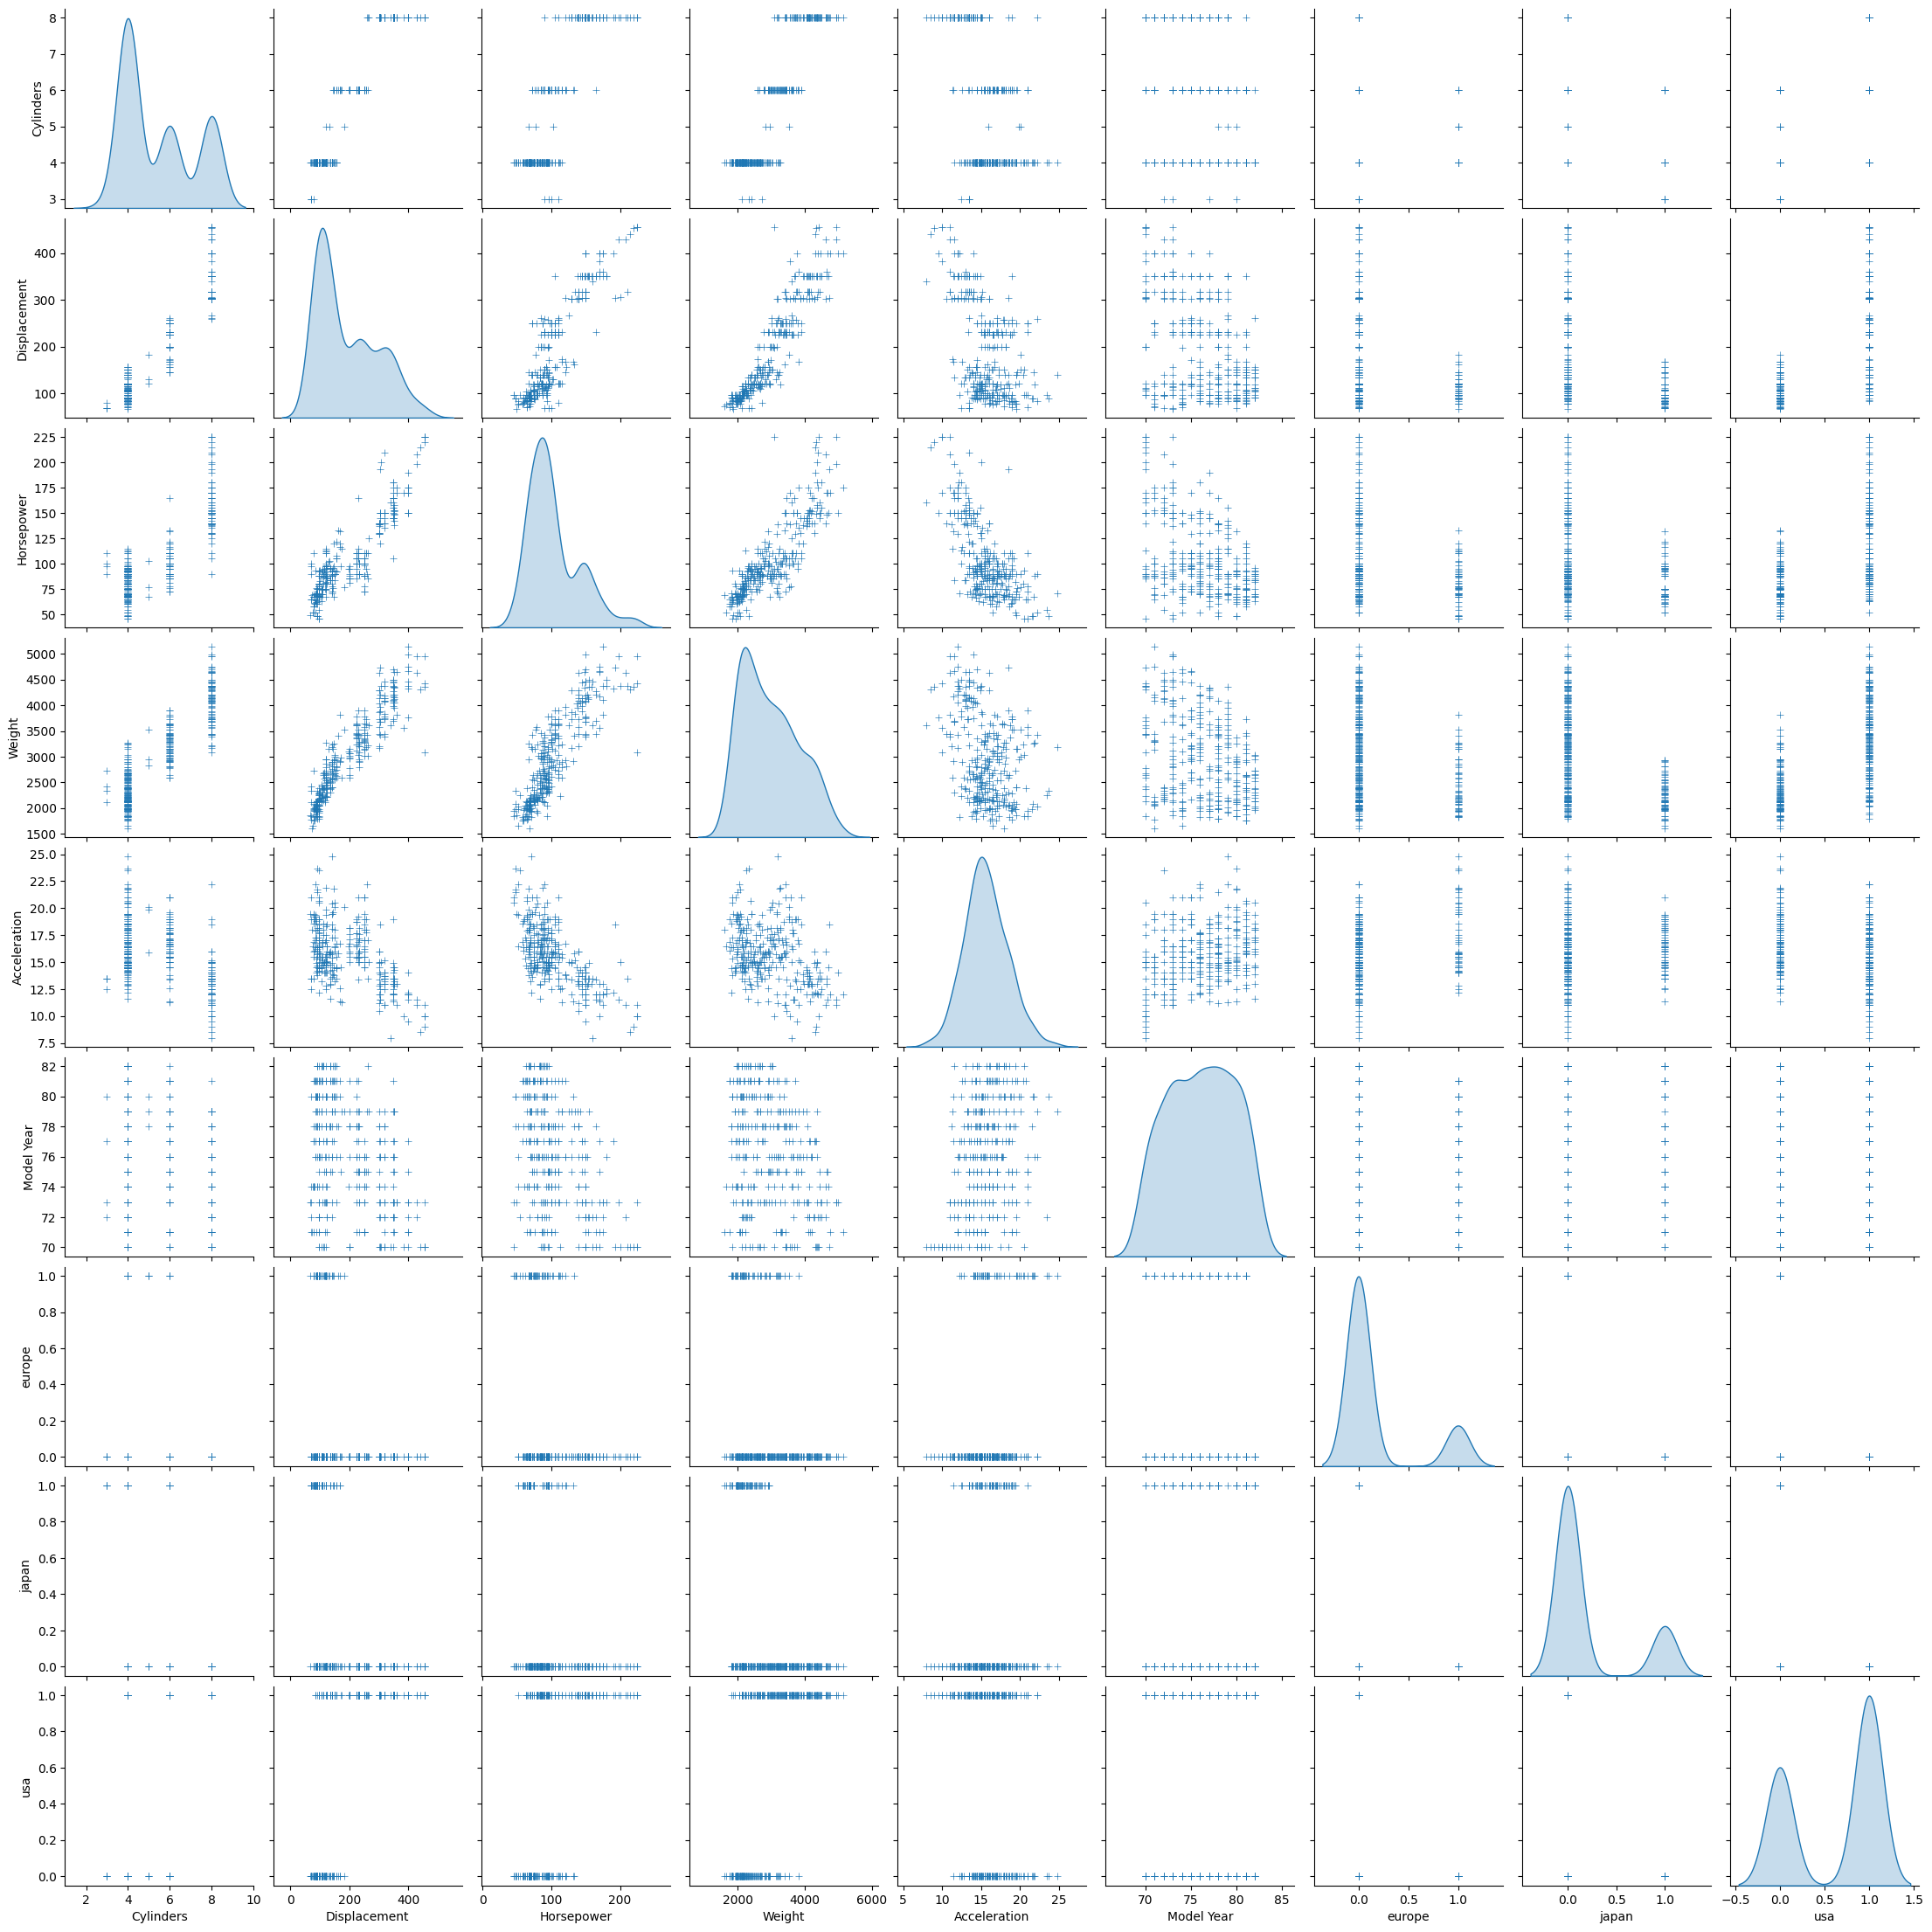

In [10]:
import seaborn as sns

sns.pairplot(X_train, 
             diag_kind="kde", 
             markers="+")

Tambien revise las estadisticas generales:

### Separa las features del target

Separe el target de las features.

In [11]:
X = df.drop('MPG', axis=1)
y = df['MPG']

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=X_train_scaled.shape[1:]),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model.compile(
    loss='mse',  # Mean Squared Error para regresión
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['mae', 'mse']  # Mean Absolute Error y Mean Squared Error
)

### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [16]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=32,
    verbose=1,
)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 17323.7168 - mae: 77.9701 - mse: 17323.7168 - val_loss: 467.8291 - val_mae: 19.9616 - val_mse: 467.8291
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 478.1353 - mae: 19.4954 - mse: 478.1353 - val_loss: 419.8869 - val_mae: 18.8646 - val_mse: 419.8869
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 440.5810 - mae: 18.8485 - mse: 440.5810 - val_loss: 521.9760 - val_mae: 19.4311 - val_mse: 521.9760
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 468.7276 - mae: 18.3787 - mse: 468.7276 - val_loss: 690.6658 - val_mae: 19.7788 - val_mse: 690.6658
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1929.7212 - mae: 35.8469 - mse: 1929.7212 - val_loss: 540.0036 - val_mae: 18.1312 - val_mse: 540.0036
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1333.9612 - mae: 31.7094 - mse: 1333.9612 - val_loss: 1325.7346 - val_mae: 28.3607 - val_mse: 1325.7346
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

In [17]:
history_dict = history.history

print(history_dict.keys())
print(history_dict.values(
    
))

history_dict['loss']

mae = history_dict['mae']
val_mae = history_dict['val_mae']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mse = history_dict['mse']
val_mse = history_dict['val_mse']


plt.plot(mae, label='Training MAE')
plt.plot(val_mae, label='Validation MAE')

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])
dict_values([[17323.716796875, 478.1352844238281, 440.58099365234375, 468.7276306152344, 1929.72119140625, 1333.961181640625, 1163.1583251953125, 1104.155029296875, 1158.102783203125, 1470.388427734375, 805.9625854492188, 1650.419189453125, 639.315185546875, 1532.6646728515625, 735.0274047851562, 295.9523010253906, 1849.5906982421875, 211.99391174316406, 1863.544677734375, 464.7987365722656, 1393.216064453125, 758.7875366210938, 1441.244384765625, 621.17626953125, 1010.3896484375, 928.6964721679688, 681.6372680664062, 1442.8212890625, 355.5777587890625, 1708.3470458984375, 184.90151977539062, 1505.9200439453125, 417.1690673828125, 1271.6064453125, 642.879638671875, 1041.1673583984375, 461.0819091796875, 1620.1424560546875, 142.82057189941406, 1578.120849609375, 355.5571594238281, 622.923828125, 1037.57470703125, 98.42290496826172, 1637.1351318359375, 229.1466522216797, 1127.241455078125, 461.9732971191406, 1328.8342285

NameError: name 'plt' is not defined

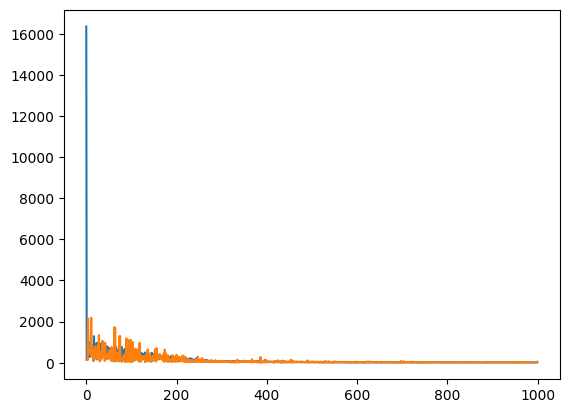

In [ ]:
plt.plot(loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')

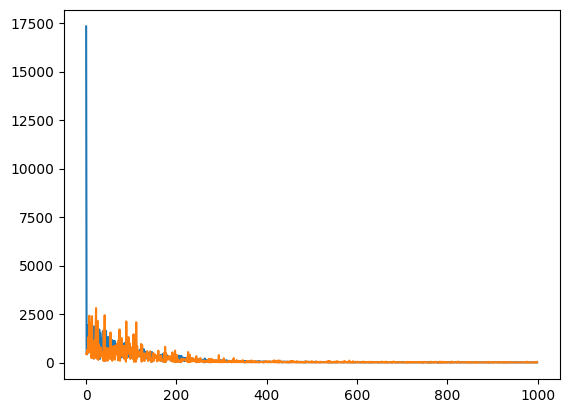

In [19]:
import matplotlib.pyplot as plt
plt.plot(mse, label='Training mse')
plt.plot(val_mse, label='Validation mse')

¿Alguna conclusión respecto a este gráfico?

el modelo se estabiliza despues de la diferencia inciial. al 600 se estabiliza . Posiblmenetebajando el epochs mejorariamos porque es ucho aprendizaje para tan pocos datos.

Earlystopping me ha ayudado a detener el entrenamiento para no caer en overfitting, también para ahorrar recursos innecesarios.

Observamos que si le damos muchas epochs al entrenamiento tiende a un overfitting, siendo el error en validación cada vez más alto. Sería interesante utilizar un número aprox de 30 epochs

Añade un early stopping al modelo. Pon el argumento `callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)]` dentro del fit().

Visualiza el progreso de entrenamiento.

In [20]:
import keras
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 17.5624 - mae: 3.2752 - mse: 17.5624 - val_loss: 10.3941 - val_mae: 2.3298 - val_mse: 10.3941
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 16.2805 - mae: 3.1634 - mse: 16.2805 - val_loss: 10.8538 - val_mae: 2.3815 - val_mse: 10.8538
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.6805 - mae: 3.0108 - mse: 14.6805 - val_loss: 14.3442 - val_mae: 2.8331 - val_mse: 14.3442
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.7437 - mae: 3.1500 - mse: 16.7437 - val_loss: 25.3423 - val_mae: 4.2418 - val_mse: 25.3423
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.0169 - mae: 2.6789 - mse: 13.0169 - val_loss: 9.3476 - val_mae: 2.2562 - val_mse: 9.3476
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.2123 - mae: 2.4688 - mse: 11.2123 - val_loss: 28.6170 - val_mae: 4.8271 - val_mse: 28.6170
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.0827 - mae: 3.6130 - mse: 20.0827 - 

Interpreta el gráfico

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])
dict_values([[17.56239891052246, 16.280498504638672, 14.68045711517334, 16.74369239807129, 13.016924858093262, 11.212285041809082, 20.082748413085938, 9.51435375213623, 17.371015548706055, 12.471596717834473, 17.441612243652344, 14.089648246765137, 12.5034818649292, 17.95404052734375, 10.186286926269531], [3.275230646133423, 3.163412094116211, 3.010819911956787, 3.1500329971313477, 2.6788980960845947, 2.468752384185791, 3.613024950027466, 2.209526538848877, 3.3021388053894043, 2.723646402359009, 3.4220869541168213, 2.8522915840148926, 2.6537539958953857, 3.272778034210205, 2.3191003799438477], [17.56239891052246, 16.280498504638672, 14.68045711517334, 16.74369239807129, 13.016924858093262, 11.212285041809082, 20.082748413085938, 9.51435375213623, 17.371015548706055, 12.471596717834473, 17.441612243652344, 14.089648246765137, 12.5034818649292, 17.95404052734375, 10.186286926269531], [10.394088745117188, 10.8538150787353

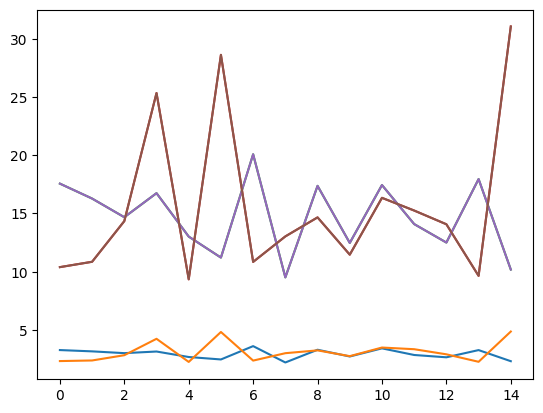

In [21]:
history_dict = history.history

print(history_dict.keys())
print(history_dict.values())

history_dict['loss']

mae = history_dict['mae']
val_mae = history_dict['val_mae']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mse = history_dict['mse']
val_mse = history_dict['val_mse']


plt.plot(mae, label='Training MAE')
plt.plot(val_mae, label='Validation MAE')
plt.plot(loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')
plt.plot(mse, label='Training mse')
plt.plot(val_mse, label='Validation mse')

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [22]:
test_loss, test_mae, test_mse = model.evaluate(X_test_scaled, y_test, verbose=1)

print("\n=== EVALUACIÓN DEL MODELO CON DATOS DE PRUEBA ===")
print(f"Pérdida (MSE) en prueba: {test_loss:.4f}")
print(f"Error Absoluto Medio (MAE) en prueba: {test_mae:.4f} MPG")
print(f"Error Cuadrático Medio (MSE) en prueba: {test_mse:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 551.8379 - mae: 22.4933 - mse: 551.8379 

=== EVALUACIÓN DEL MODELO CON DATOS DE PRUEBA ===
Pérdida (MSE) en prueba: 551.8379
Error Absoluto Medio (MAE) en prueba: 22.4933 MPG
Error Cuadrático Medio (MSE) en prueba: 551.8379


Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [23]:
import numpy as np
y_pred = model.predict(X_test)

resultados = pd.DataFrame({
    'Valor Real': y_test.values.flatten(),
    'Valor Predicho': y_pred.flatten(),
    'Error Absoluto': np.abs(y_test.values.flatten() - y_pred.flatten()),
    'Error Porcentual': np.abs((y_test.values.flatten() - y_pred.flatten()) / y_test.values.flatten()) * 100
})

print(resultados.head(10))
print(f"Error Absoluto Medio (MAE): {resultados['Error Absoluto'].mean():.4f} MPG")
print(f"Error Absoluto Máximo: {resultados['Error Absoluto'].max():.4f} MPG")
print(f"Error Absoluto Mínimo: {resultados['Error Absoluto'].min():.4f} MPG")
print(f"Desviación Estándar del Error: {resultados['Error Absoluto'].std():.4f}")
print(f"Error Porcentual Medio: {resultados['Error Porcentual'].mean():.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
   Valor Real  Valor Predicho  Error Absoluto  Error Porcentual
0        33.0       30.659363        2.340637          7.092840
1        28.0       25.040409        2.959591         10.569968
2        19.0       15.260557        3.739443         19.681278
3        13.0       10.708618        2.291382         17.626014
4        14.0        9.675219        4.324781         30.891296
5        27.0       23.255016        3.744984         13.870310
6        24.0       20.911682        3.088318         12.867991
7        13.0        7.708590        5.291410         40.703154
8        17.0       12.367067        4.632933         27.252545
9        21.0       15.964060        5.035940         23.980667
Error Absoluto Medio (MAE): 4.7448 MPG
Error Absoluto Máximo: 9.7838 MPG
Error Absoluto Mínimo: 0.0952 MPG
Desviación Estándar del Error: 2.1980
Error Porcentual Medio: 22.31%


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

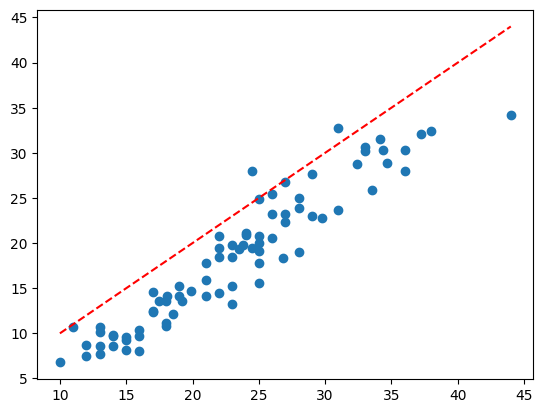

In [24]:

plt.scatter(resultados['Valor Real'], resultados['Valor Predicho'])

max_val = resultados['Valor Real'].max()
min_val = resultados['Valor Real'].min()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')


Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

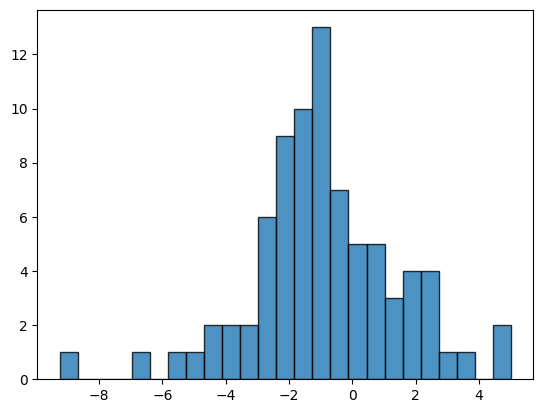

In [ ]:
residuos = resultados['Valor Real'] - resultados['Valor Predicho']

plt.hist(residuos, bins=25, edgecolor='black', alpha=0.8)
plt.show()

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [ ]:
model.save('mi_modelo_mpg.keras')

## Conclusion

En la grafica scatterplot vemos que sigue una tendencia de 45% por lo tanto podríamos decir que las predicciones son bastante acertadas.

Importante no pasarnos de epochs con los primeros 1000 nos habiamos pasad ya que tenemos pocos datos .